# Evaluación de modelos tabulares (monthly / annual)

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.eda import load_processed_dataset, load_tiff_as_dataarray
from src.training.train import load_trained_pipeline
from src.evaluation.regression import (
    compute_global_regression_metrics,
    compute_pixel_regression_metrics,
    summarize_pixel_metrics,
    rank_best_and_worst_pixels,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [24]:
# CONFIGURACIÓN
MAIN_DIR = Path("/home/dani/github/profecia/data")
PROCESSED_BASE_DIR = MAIN_DIR / "processed"
SPLITS_BASE_DIR = MAIN_DIR / "splits"
MODELS_BASE_DIR = MAIN_DIR / "models"

temporal_resolution = "annual"   # "monthly" o "annual"
split_type = "landcover"         # "landcover" o "climate"
model_run_name = "annual_landcover_rf"

VARIABLE_NAMES = ["LAI", "SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]

PROCESSED_DIR = PROCESSED_BASE_DIR / temporal_resolution
INPUT_DIR = SPLITS_BASE_DIR / temporal_resolution / split_type 
MODELS_DIR = MODELS_BASE_DIR / temporal_resolution / split_type

MODEL_PATH = MODELS_DIR / f"{model_run_name}_model.joblib"
SCALER_PATH = MODELS_DIR / f"{model_run_name}_scaler.joblib"
TRAIN_INFO_PATH = MODELS_DIR / f"{model_run_name}_train_info.json"

CLIMATE_TIFF = Path("/home/dani/github/profecia/data/masks/climate") /"Beck_KG_V1_present_0p5_5climates.tif"
LANDCOVER_TIFF = Path("/home/dani/github/profecia/data/masks/landcover") / "GLASS-GLC_7classes_2000_0p5_dominant.tif"

print("PROCESSED_DIR:", PROCESSED_DIR)
print("INPUT_DIR:", INPUT_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("MODEL_PATH exists:", MODEL_PATH.exists())
print("SCALER_PATH exists:", SCALER_PATH.exists())
print("TRAIN_INFO_PATH exists:", TRAIN_INFO_PATH.exists())

PROCESSED_DIR: /home/dani/github/profecia/data/processed/annual
INPUT_DIR: /home/dani/github/profecia/data/splits/annual/landcover
MODELS_DIR: /home/dani/github/profecia/data/models/annual/landcover
MODEL_PATH exists: True
SCALER_PATH exists: False
TRAIN_INFO_PATH exists: True


In [4]:
macro_labels = {
    0: "NoData",
    1: "Tropical",
    2: "Arid",
    3: "Temperate",
    4: "Cold",
    5: "Polar"
}

lc_labels = {
    0: "NoData",
    10: "Cropland",
    20: "Forest",
    30: "Grassland",
    40: "Shrubland",
    70: "Tundra",
    90: "Barren land",
    100: "Snow/Ice"
}

## Cargar dataset procesado para recuperar grid, LAI y coordenadas

In [5]:
data_dict, metadata = load_processed_dataset(
    input_dir=PROCESSED_DIR,
    variable_names=VARIABLE_NAMES,
    reference_variable="LAI",
)

lai = data_dict["LAI"]
predictor_names = [v for v in VARIABLE_NAMES if v != "LAI"]

print("Variables cargadas:", list(data_dict.keys()))
print("Shape LAI:", lai.shape)
print("Dims LAI:", lai.dims)
print("Tiempo:", str(pd.to_datetime(lai.time.values[0]))[:10], "->", str(pd.to_datetime(lai.time.values[-1]))[:10])
print("Latitud:", float(lai.latitude.min()), "->", float(lai.latitude.max()))
print("Longitud:", float(lai.longitude.min()), "->", float(lai.longitude.max()))

Variables cargadas: ['LAI', 'SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD']
Shape LAI: (41, 360, 720)
Dims LAI: ('time', 'latitude', 'longitude')
Tiempo: 1982-01-01 -> 2022-01-01
Latitud: -90.0 -> 89.5
Longitud: -180.0 -> 179.5


## Cargar arrays de test exportados por el split

In [6]:
X_test = np.load(INPUT_DIR / "X_test.npy", mmap_mode="r")
y_test = np.load(INPUT_DIR / "y_test.npy", mmap_mode="r")
pixel_id_test = np.load(INPUT_DIR / "pixel_id_test.npy", mmap_mode="r")
lat_idx_test = np.load(INPUT_DIR / "lat_idx_test.npy", mmap_mode="r")
lon_idx_test = np.load(INPUT_DIR / "lon_idx_test.npy", mmap_mode="r")
time_idx_test = np.load(INPUT_DIR / "time_idx_test.npy", mmap_mode="r")

with open(INPUT_DIR / "dataset_metadata.json", "r", encoding="utf-8") as f:
    dataset_metadata = json.load(f)

print("X_test:", X_test.shape, X_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)
print("n test samples:", len(y_test))
print("n unique test pixels:", len(np.unique(pixel_id_test)))
print("temporal_resolution_inferred:", dataset_metadata.get("temporal_resolution_inferred"))

X_test: (130572, 6) float32
y_test: (130572,) float32
n test samples: 130572
n unique test pixels: 3200
temporal_resolution_inferred: annual


## Cargar modelo y scaler

In [7]:
with open(TRAIN_INFO_PATH, "r", encoding="utf-8") as f:
    train_info = json.load(f)

scaler_path = train_info.get("scaler_path")
scaler_path = Path(scaler_path) if scaler_path is not None else None

model, scaler = load_trained_pipeline(
    model_path=MODEL_PATH,
    scaler_path=scaler_path,
)

print("Modelo:", train_info.get("model_name"))
print("Scaler:", train_info.get("scaler_name"))
print("Target:", train_info.get("target"))
print("Feature names:", train_info.get("feature_names"))

Modelo: RandomForestRegressor
Scaler: none
Target: LAI
Feature names: ['SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD']


## Transformar test si procede y predecir

In [8]:
if scaler is not None:
    X_test_used = scaler.transform(X_test)
    X_test_used = X_test_used.astype(np.float32, copy=False)
else:
    X_test_used = X_test

y_pred = model.predict(X_test_used)
y_pred = np.asarray(y_pred).reshape(-1)

print("Predicciones:", y_pred.shape)

Predicciones: (130572,)


## Métricas globales

In [9]:
global_metrics = compute_global_regression_metrics(
    y_true=y_test,
    y_pred=y_pred,
)

global_metrics

{'r2': 0.8625829786382238,
 'rmse': 0.4464382001844435,
 'mae': 0.2723536799069317,
 'n_samples': 130572}

## Scatter global real vs predicho

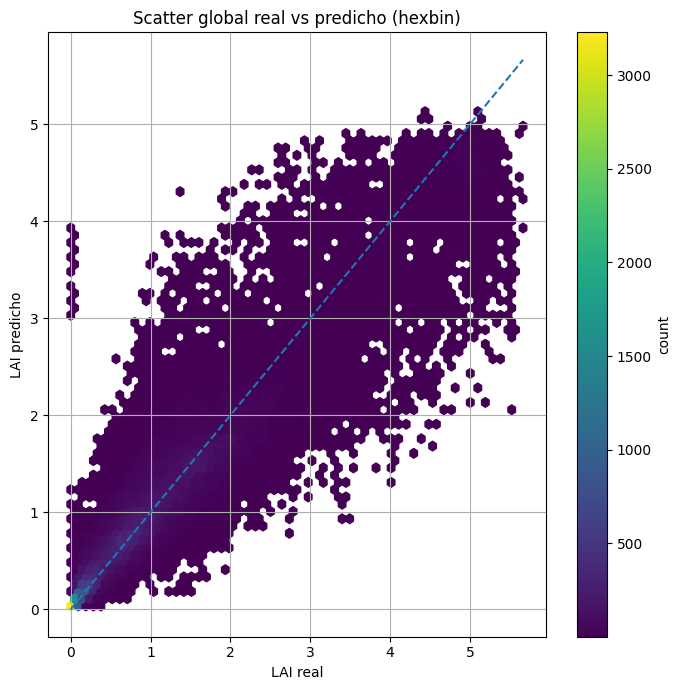

In [10]:
rng = np.random.default_rng(42)
n_plot = min(50000, len(y_test))
idx = rng.choice(len(y_test), size=n_plot, replace=False) if len(y_test) > n_plot else np.arange(len(y_test))

y_true_plot = np.asarray(y_test)[idx]
y_pred_plot = np.asarray(y_pred)[idx]

fig, ax = plt.subplots(figsize=(7, 7))
hb = ax.hexbin(y_true_plot, y_pred_plot, gridsize=60, mincnt=1)
lims = [
    min(np.nanmin(y_true_plot), np.nanmin(y_pred_plot)),
    max(np.nanmax(y_true_plot), np.nanmax(y_pred_plot)),
]
ax.plot(lims, lims, linestyle="--")
ax.set_xlabel("LAI real")
ax.set_ylabel("LAI predicho")
ax.set_title("Scatter global real vs predicho (hexbin)")
plt.colorbar(hb, ax=ax, label="count")
plt.tight_layout()
plt.show()

## Métricas por píxel

In [11]:
latitude_per_row = lai.latitude.values[np.asarray(lat_idx_test)]
longitude_per_row = lai.longitude.values[np.asarray(lon_idx_test)]

pixel_metrics_df = compute_pixel_regression_metrics(
    y_true=y_test,
    y_pred=y_pred,
    pixel_id=pixel_id_test,
    lat_idx=lat_idx_test,
    lon_idx=lon_idx_test,
    latitude=latitude_per_row,
    longitude=longitude_per_row,
)

pixel_metrics_df.head()

,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude
0,50617,41,-2445.219644,0.197694,0.170866,0.000016,70,217,-55.0,-71.5
1,50628,41,-194.296825,0.417537,0.409028,0.000893,70,228,-55.0,-66.0
2,51341,41,-386.661449,0.434858,0.418420,0.000488,71,221,-54.5,-69.5
3,52052,41,-12690.003456,0.350943,0.338808,0.000010,72,212,-54.0,-74.0
4,54219,41,-62.162729,0.512491,0.503479,0.004158,75,219,-52.5,-70.5


## Resumen de métricas por píxel

In [12]:
pixel_metrics_summary = summarize_pixel_metrics(pixel_metrics_df)
pixel_metrics_summary

{'n_pixels': 3200,
 'n_pixels_valid_r2': 3173,
 'n_pixels_nan_r2': 27,
 'r2_mean': -4737.045213265018,
 'r2_median': -9.968597747529818,
 'r2_p05': -875.7119919777954,
 'r2_p95': -0.3202232883469586,
 'rmse_mean': 0.3054830910137683,
 'rmse_median': 0.20617846474849855,
 'mae_mean': 0.27181507589831516,
 'mae_median': 0.17224265185680926,
 'y_true_variance_mean': 0.008023069650713083,
 'y_true_variance_median': 0.004309010924771428}

## Mejores y peores píxeles por R²

In [13]:
rank_r2 = rank_best_and_worst_pixels(
    pixel_metrics_df=pixel_metrics_df,
    metric="r2",
    top_k=20,
)

best_pixels_r2 = rank_r2["best"]
worst_pixels_r2 = rank_r2["worst"]

display(best_pixels_r2.head(10))
display(worst_pixels_r2.head(10))

,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude
0,94729,41,0.635101,0.069851,0.053734,0.013371,131,409,-24.5,24.5
1,84895,41,0.550081,0.157727,0.131246,0.055294,117,655,-31.5,147.5
2,85571,41,0.540476,0.110115,0.093171,0.026387,118,611,-31.0,125.5
3,99977,41,0.531618,0.040822,0.032701,0.003558,138,617,-21.0,128.5
4,92793,41,0.513786,0.042895,0.035130,0.003784,128,633,-26.0,136.5
5,92552,41,0.485688,0.024782,0.018173,0.001194,128,392,-26.0,16.0
6,94954,41,0.458578,0.045695,0.036252,0.003857,131,634,-24.5,137.0
7,97802,41,0.457694,0.044587,0.032899,0.003666,135,602,-22.5,121.0
8,102141,41,0.454183,0.068345,0.057573,0.008558,141,621,-19.5,130.5
9,101419,41,0.441752,0.060598,0.047300,0.006578,140,619,-20.0,129.5


,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude
0,136679,41,-5.574170e+06,3.449707,3.435886,2.134932e-06,189,599,4.5,119.5
1,105816,41,-1.181655e+06,1.611597,1.577239,2.197970e-06,146,696,-17.0,168.0
2,120169,41,-8.256264e+05,0.593261,0.527462,4.262918e-07,166,649,-7.0,144.5
3,191706,41,-7.035957e+05,1.003813,0.987705,1.432128e-06,266,186,43.0,-87.0
4,121621,41,-5.814562e+05,1.324013,1.287028,3.014856e-06,168,661,-6.0,150.5
5,115142,41,-4.885005e+05,1.780108,1.753126,6.486748e-06,159,662,-10.5,151.0
6,142041,41,-4.815620e+05,3.678836,3.675222,2.810398e-05,197,201,8.5,-79.5
7,108208,41,-4.608383e+05,0.096961,0.094038,2.040063e-08,150,208,-15.0,-76.0
8,123052,41,-4.136458e+05,1.452819,1.428016,5.102623e-06,170,652,-5.0,146.0
9,140309,41,-3.720012e+05,1.290901,1.259636,4.479609e-06,194,629,7.0,134.5


## Histogramas de métricas por píxel

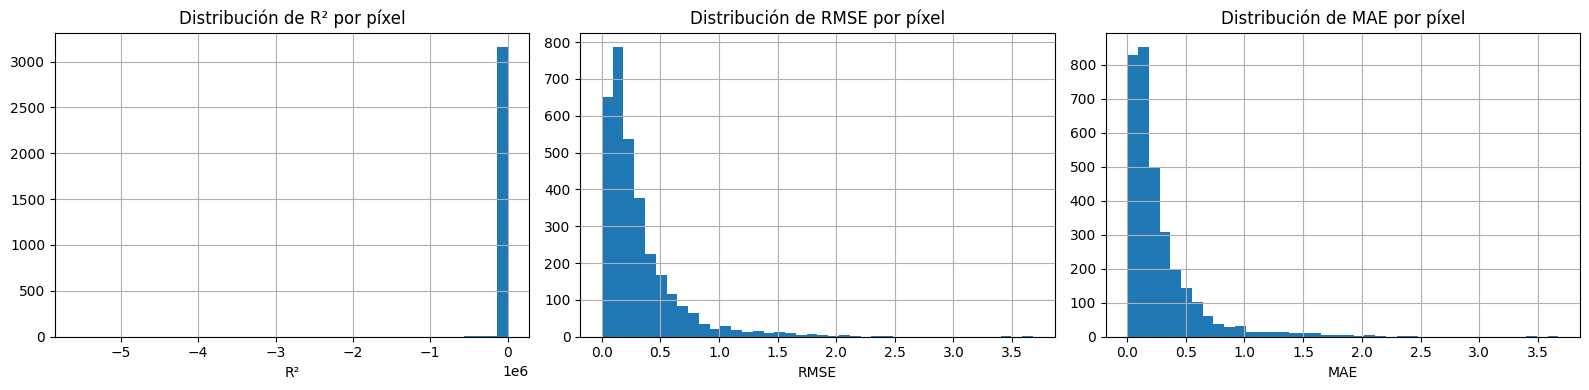

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(pixel_metrics_df["r2"].dropna(), bins=40)
axes[0].set_title("Distribución de R² por píxel")
axes[0].set_xlabel("R²")

axes[1].hist(pixel_metrics_df["rmse"].dropna(), bins=40)
axes[1].set_title("Distribución de RMSE por píxel")
axes[1].set_xlabel("RMSE")

axes[2].hist(pixel_metrics_df["mae"].dropna(), bins=40)
axes[2].set_title("Distribución de MAE por píxel")
axes[2].set_xlabel("MAE")

plt.tight_layout()
plt.show()

## Clasificar R² en 4 grupos

In [15]:
pixel_metrics_plot = pixel_metrics_df.copy()

def classify_r2(x):
    if pd.isna(x):
        return "NaN"
    if x < 0:
        return "Negative"
    if x < 0.25:
        return "Poor"
    if x < 0.50:
        return "Medium"
    return "Good"

pixel_metrics_plot["r2_class"] = pixel_metrics_plot["r2"].apply(classify_r2)
pixel_metrics_plot["r2_class"].value_counts(dropna=False)

r2_class
Negative    3104
Poor          40
NaN           27
Medium        24
Good           5
Name: count, dtype: int64

## Cargar máscaras de clima y land cover

In [25]:
climate_mask = load_tiff_as_dataarray(
    tiff_path=CLIMATE_TIFF,
    latitude=lai.latitude.values,
    longitude=lai.longitude.values,
    name="climate_mask",
)

landcover_mask = load_tiff_as_dataarray(
    tiff_path=LANDCOVER_TIFF,
    latitude=lai.latitude.values,
    longitude=lai.longitude.values,
    name="landcover_mask",
)

print(climate_mask.shape, landcover_mask.shape)

(360, 720) (360, 720)


## Añadir clima y land cover a cada píxel

In [26]:
pixel_metrics_plot["climate_code"] = [
    int(climate_mask.values[int(i), int(j)]) for i, j in zip(pixel_metrics_plot["lat_idx"], pixel_metrics_plot["lon_idx"])
]
pixel_metrics_plot["landcover_code"] = [
    int(landcover_mask.values[int(i), int(j)]) for i, j in zip(pixel_metrics_plot["lat_idx"], pixel_metrics_plot["lon_idx"])
]

pixel_metrics_plot["climate_label"] = pixel_metrics_plot["climate_code"].map(macro_labels).fillna("Unknown")
pixel_metrics_plot["landcover_label"] = pixel_metrics_plot["landcover_code"].map(lc_labels).fillna("Unknown")

pixel_metrics_plot.head()

,pixel_id,n_samples,r2,rmse,mae,y_true_variance,lat_idx,lon_idx,latitude,longitude,r2_class,climate_code,landcover_code,climate_label,landcover_label
0,50617,41,-2445.219644,0.197694,0.170866,0.000016,70,217,-55.0,-71.5,Negative,5,30,Polar,Grassland
1,50628,41,-194.296825,0.417537,0.409028,0.000893,70,228,-55.0,-66.0,Negative,5,30,Polar,Grassland
2,51341,41,-386.661449,0.434858,0.418420,0.000488,71,221,-54.5,-69.5,Negative,5,30,Polar,Grassland
3,52052,41,-12690.003456,0.350943,0.338808,0.000010,72,212,-54.0,-74.0,Negative,5,30,Polar,Grassland
4,54219,41,-62.162729,0.512491,0.503479,0.004158,75,219,-52.5,-70.5,Negative,2,30,Arid,Grassland


# Análisis por land cover

In [27]:
landcover_summary = (
    pixel_metrics_plot
    .groupby(["landcover_code", "landcover_label", "r2_class"])
    .size()
    .reset_index(name="n_pixels")
)

landcover_total = (
    pixel_metrics_plot
    .groupby(["landcover_code", "landcover_label"])
    .size()
    .reset_index(name="n_total")
)

landcover_summary = landcover_summary.merge(
    landcover_total,
    on=["landcover_code", "landcover_label"],
    how="left",
)

landcover_summary["pct"] = 100 * landcover_summary["n_pixels"] / landcover_summary["n_total"]
landcover_summary.head()

,landcover_code,landcover_label,r2_class,n_pixels,n_total,pct
0,10,Cropland,Negative,301,301,100.000000
1,20,Forest,Medium,1,1002,0.099800
2,20,Forest,Negative,992,1002,99.001996
3,20,Forest,Poor,9,1002,0.898204
4,30,Grassland,Medium,5,564,0.886525


In [28]:
landcover_summary_round = (
    landcover_summary
    .pivot(index=["landcover_code", "landcover_label"], columns="r2_class", values="pct")
    .fillna(0)
    .reset_index()
)

for c in ["Negative", "Poor", "Medium", "Good", "NaN"]:
    if c not in landcover_summary_round.columns:
        landcover_summary_round[c] = 0.0

landcover_summary_round = landcover_summary_round.sort_values("landcover_code")
landcover_summary_round.head()

r2_class,landcover_code,landcover_label,Good,Medium,NaN,Negative,Poor
0,10,Cropland,0.000000,0.000000,0.0,100.000000,0.000000
1,20,Forest,0.000000,0.099800,0.0,99.001996,0.898204
2,30,Grassland,0.000000,0.886525,0.0,98.049645,1.063830
3,40,Shrubland,0.593472,1.483680,0.0,94.955490,2.967359
4,70,Tundra,0.000000,0.602410,0.0,98.192771,1.204819


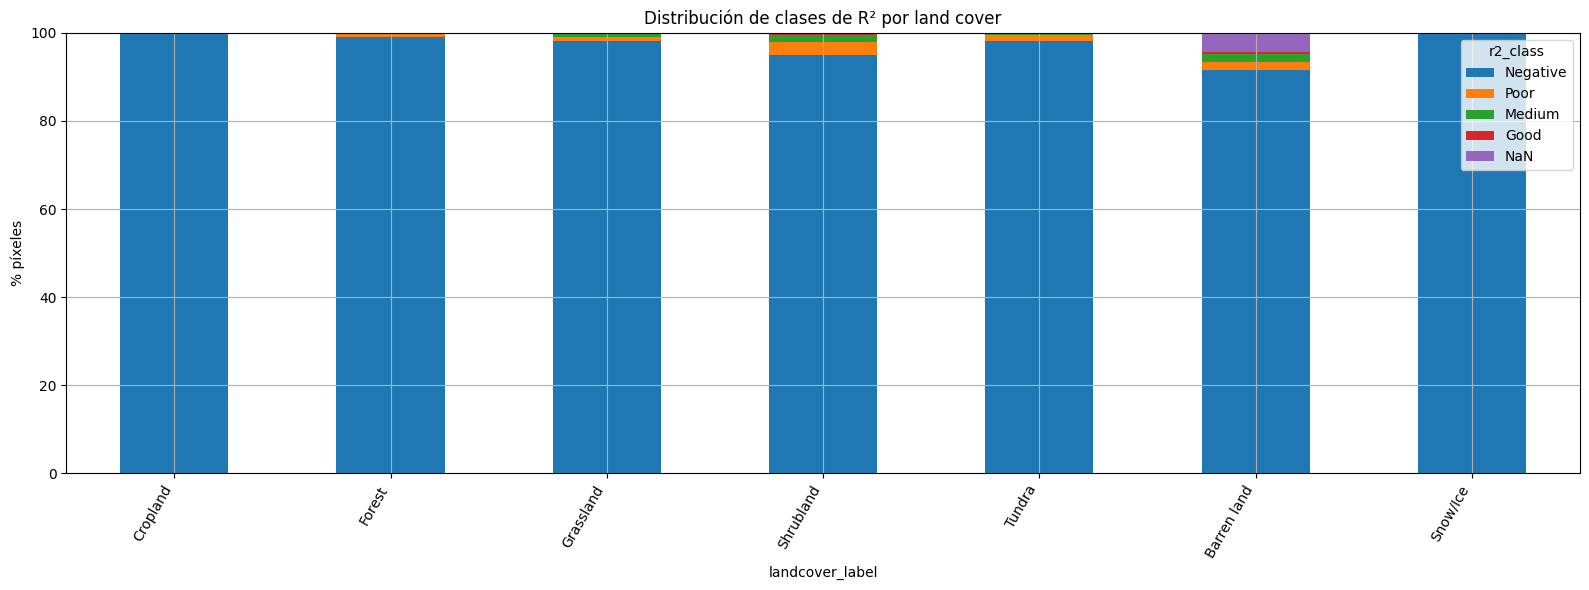

In [29]:
plot_df = landcover_summary_round.set_index("landcover_label")[["Negative", "Poor", "Medium", "Good", "NaN"]]
ax = plot_df.plot(kind="bar", stacked=True, figsize=(16, 6))
ax.set_ylabel("% píxeles")
ax.set_title("Distribución de clases de R² por land cover")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Análisis por clima

In [30]:
climate_summary = (
    pixel_metrics_plot
    .groupby(["climate_code", "climate_label", "r2_class"])
    .size()
    .reset_index(name="n_pixels")
)

climate_total = (
    pixel_metrics_plot
    .groupby(["climate_code", "climate_label"])
    .size()
    .reset_index(name="n_total")
)

climate_summary = climate_summary.merge(
    climate_total,
    on=["climate_code", "climate_label"],
    how="left",
)

climate_summary["pct"] = 100 * climate_summary["n_pixels"] / climate_summary["n_total"]
climate_summary.head()

,climate_code,climate_label,r2_class,n_pixels,n_total,pct
0,0,NoData,Negative,51,51,100.000000
1,1,Tropical,Negative,535,535,100.000000
2,2,Arid,Good,5,919,0.544070
3,2,Arid,Medium,20,919,2.176279
4,2,Arid,NaN,27,919,2.937976


In [31]:
climate_summary_round = (
    climate_summary
    .pivot(index=["climate_code", "climate_label"], columns="r2_class", values="pct")
    .fillna(0)
    .reset_index()
)

for c in ["Negative", "Poor", "Medium", "Good", "NaN"]:
    if c not in climate_summary_round.columns:
        climate_summary_round[c] = 0.0

climate_summary_round = climate_summary_round.sort_values("climate_code")
climate_summary_round.head()

r2_class,climate_code,climate_label,Good,Medium,NaN,Negative,Poor
0,0,NoData,0.00000,0.000000,0.000000,100.000000,0.000000
1,1,Tropical,0.00000,0.000000,0.000000,100.000000,0.000000
2,2,Arid,0.54407,2.176279,2.937976,91.730141,2.611534
3,3,Temperate,0.00000,0.000000,0.000000,100.000000,0.000000
4,4,Cold,0.00000,0.295858,0.000000,98.126233,1.577909


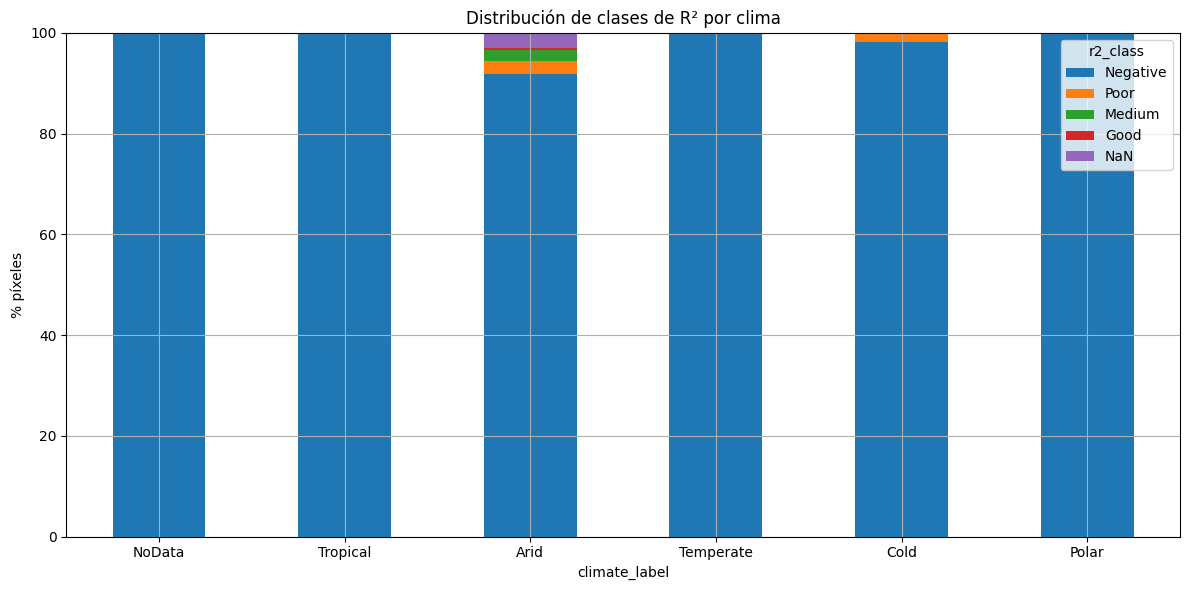

In [32]:
plot_df = climate_summary_round.set_index("climate_label")[["Negative", "Poor", "Medium", "Good", "NaN"]]
ax = plot_df.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_ylabel("% píxeles")
ax.set_title("Distribución de clases de R² por clima")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis de R² vs varianza temporal de LAI

In [33]:
lai_var_map = lai.var(dim="time", skipna=True)
lai_std_map = lai.std(dim="time", skipna=True)

pixel_metrics_plot["lai_var"] = [
    float(lai_var_map.values[int(i), int(j)]) for i, j in zip(pixel_metrics_plot["lat_idx"], pixel_metrics_plot["lon_idx"])
]
pixel_metrics_plot["lai_std"] = [
    float(lai_std_map.values[int(i), int(j)]) for i, j in zip(pixel_metrics_plot["lat_idx"], pixel_metrics_plot["lon_idx"])
]

pixel_metrics_plot[["pixel_id", "r2", "lai_var", "lai_std"]].head()

/home/dani/github/profecia/.venv/lib/python3.12/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
/home/dani/github/profecia/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,pixel_id,r2,lai_var,lai_std
0,50617,-2445.219644,0.000016,0.003997
1,50628,-194.296825,0.000893,0.029878
2,51341,-386.661449,0.000488,0.022086
3,52052,-12690.003456,0.000010,0.003115
4,54219,-62.162729,0.004158,0.064485


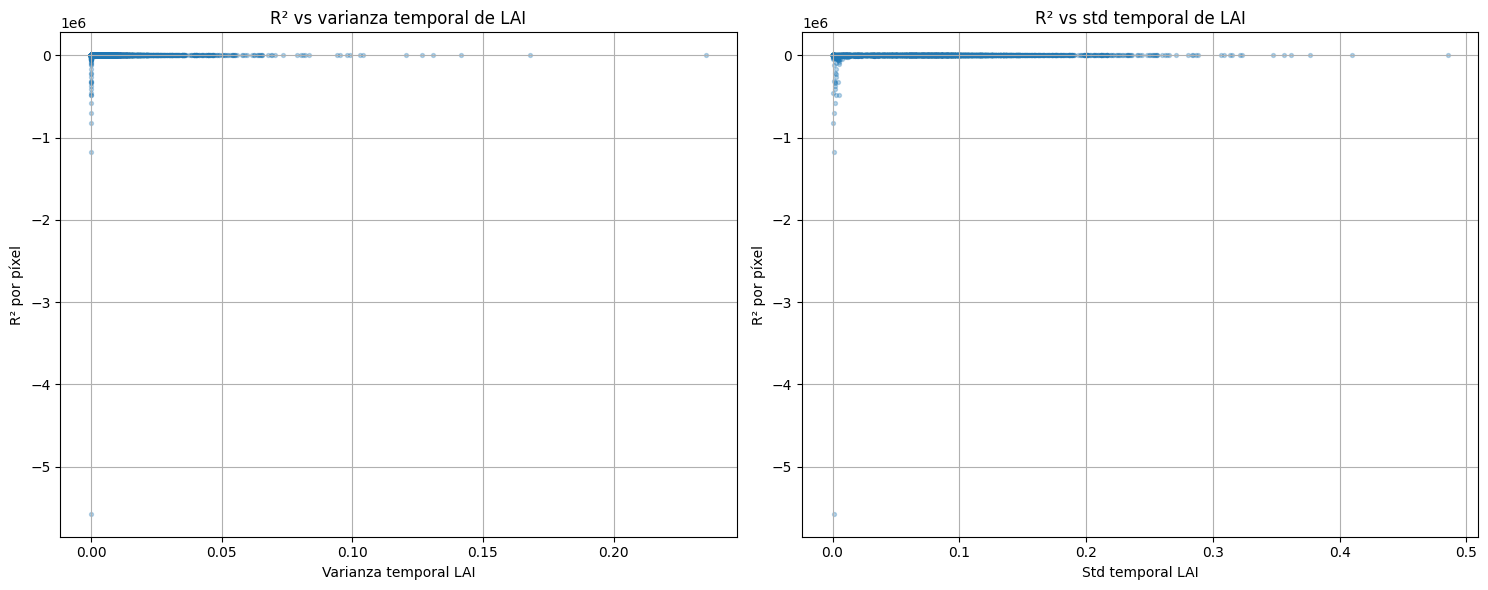

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(pixel_metrics_plot["lai_var"], pixel_metrics_plot["r2"], s=8, alpha=0.3)
axes[0].set_xlabel("Varianza temporal LAI")
axes[0].set_ylabel("R² por píxel")
axes[0].set_title("R² vs varianza temporal de LAI")

axes[1].scatter(pixel_metrics_plot["lai_std"], pixel_metrics_plot["r2"], s=8, alpha=0.3)
axes[1].set_xlabel("Std temporal LAI")
axes[1].set_ylabel("R² por píxel")
axes[1].set_title("R² vs std temporal de LAI")

plt.tight_layout()
plt.show()

## Construir DataFrame de test con trazabilidad temporal

In [35]:
time_values = pd.to_datetime(dataset_metadata["time_values"])

test_df = pd.DataFrame({
    "y_true": np.asarray(y_test),
    "y_pred": np.asarray(y_pred),
    "pixel_id": np.asarray(pixel_id_test).astype(np.int64),
    "lat_idx": np.asarray(lat_idx_test).astype(np.int32),
    "lon_idx": np.asarray(lon_idx_test).astype(np.int32),
    "time_idx": np.asarray(time_idx_test).astype(np.int32),
})

test_df["time"] = time_values[test_df["time_idx"].values]
test_df["latitude"] = lai.latitude.values[test_df["lat_idx"].values]
test_df["longitude"] = lai.longitude.values[test_df["lon_idx"].values]
test_df["residual"] = test_df["y_true"] - test_df["y_pred"]
test_df.head()

,y_true,y_pred,pixel_id,lat_idx,lon_idx,time_idx,time,latitude,longitude,residual
0,0.800000,0.564042,50617,70,217,0,1982-01-01,-55.0,-71.5,0.235958
1,1.905556,1.509120,50628,70,228,0,1982-01-01,-55.0,-66.0,0.396435
2,1.447222,0.911495,51341,71,221,0,1982-01-01,-54.5,-69.5,0.535727
3,0.307407,0.645509,52052,72,212,0,1982-01-01,-54.0,-74.0,-0.338101
4,0.594444,1.067282,54219,75,219,0,1982-01-01,-52.5,-70.5,-0.472838


## Density scatters de los 4 mejores y 4 peores píxeles

In [36]:
top4_best = best_pixels_r2.head(4).copy()
top4_worst = worst_pixels_r2.head(4).copy()

selected_pixels_density = pd.concat([
    top4_best.assign(group="best"),
    top4_worst.assign(group="worst"),
], ignore_index=True)

selected_pixels_density[["group", "pixel_id", "r2", "rmse", "mae"]]

,group,pixel_id,r2,rmse,mae
0,best,94729,6.351007e-01,0.069851,0.053734
1,best,84895,5.500807e-01,0.157727,0.131246
2,best,85571,5.404762e-01,0.110115,0.093171
3,best,99977,5.316178e-01,0.040822,0.032701
4,worst,136679,-5.574170e+06,3.449707,3.435886
5,worst,105816,-1.181655e+06,1.611597,1.577239
6,worst,120169,-8.256264e+05,0.593261,0.527462
7,worst,191706,-7.035957e+05,1.003813,0.987705


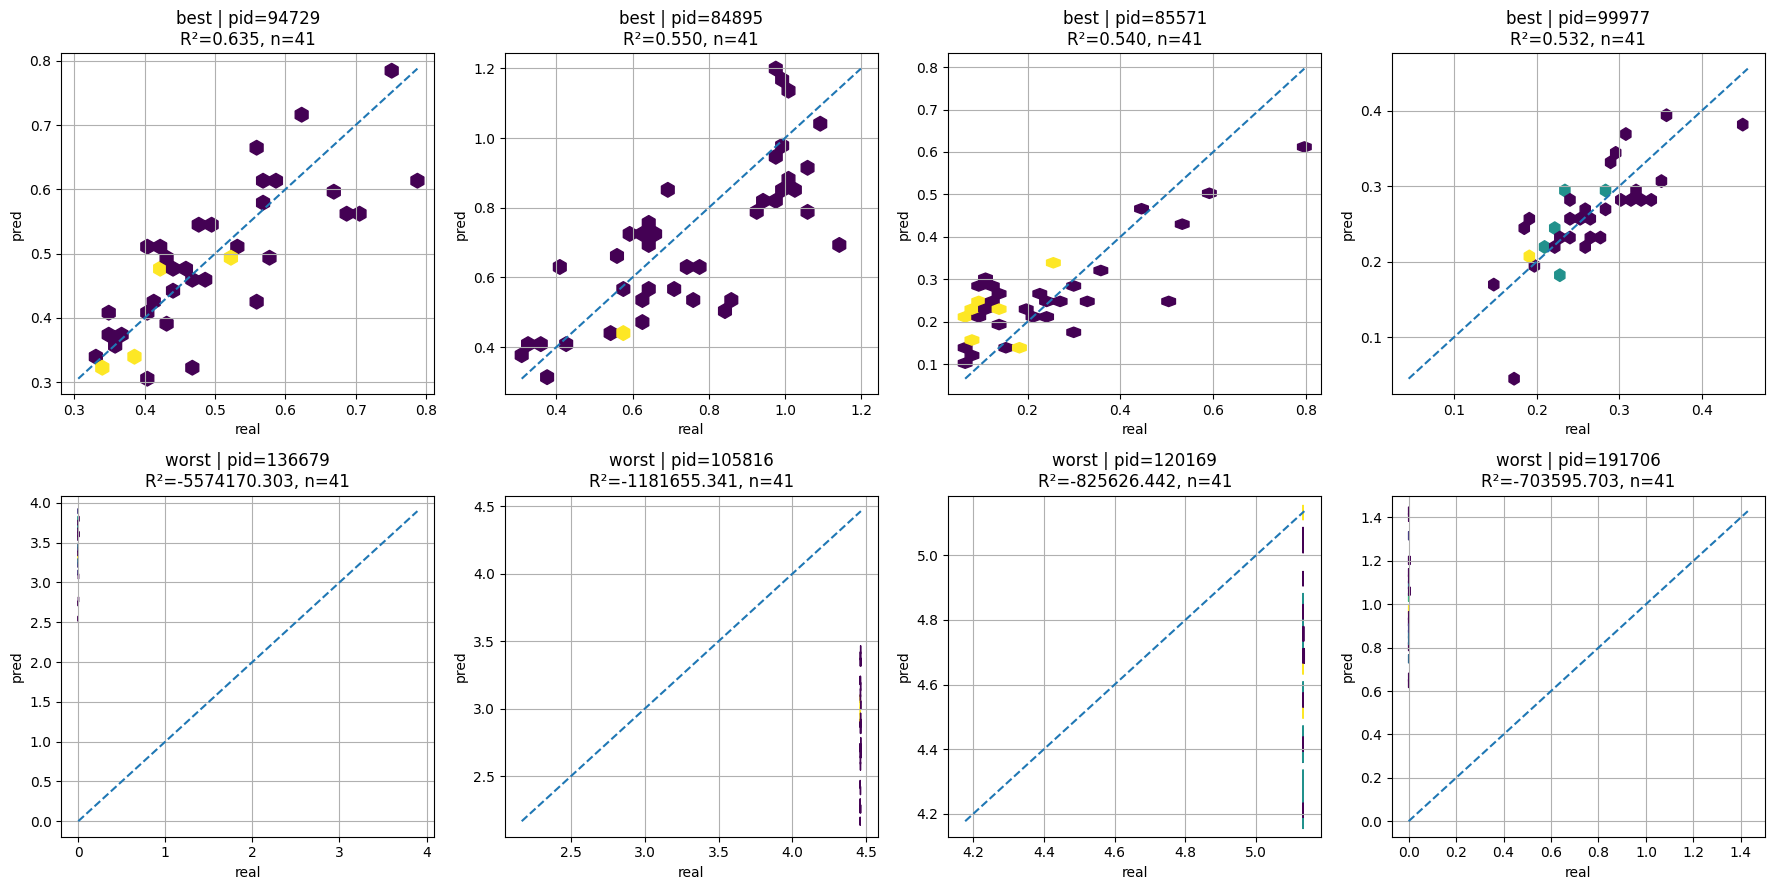

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for ax, (_, row) in zip(axes, selected_pixels_density.iterrows()):
    pid = int(row["pixel_id"])
    sub = test_df[test_df["pixel_id"] == pid].copy()

    if len(sub) == 0:
        ax.set_visible(False)
        continue

    hb = ax.hexbin(sub["y_true"], sub["y_pred"], gridsize=25, mincnt=1)
    lims = [
        min(sub["y_true"].min(), sub["y_pred"].min()),
        max(sub["y_true"].max(), sub["y_pred"].max()),
    ]
    ax.plot(lims, lims, linestyle="--")
    ax.set_title(
        f"{row['group']} | pid={pid}\nR²={row['r2']:.3f}, n={int(row['n_samples'])}"
    )
    ax.set_xlabel("real")
    ax.set_ylabel("pred")

plt.tight_layout()
plt.show()

## Series temporales real vs predicha de los 4 mejores y 4 peores píxeles

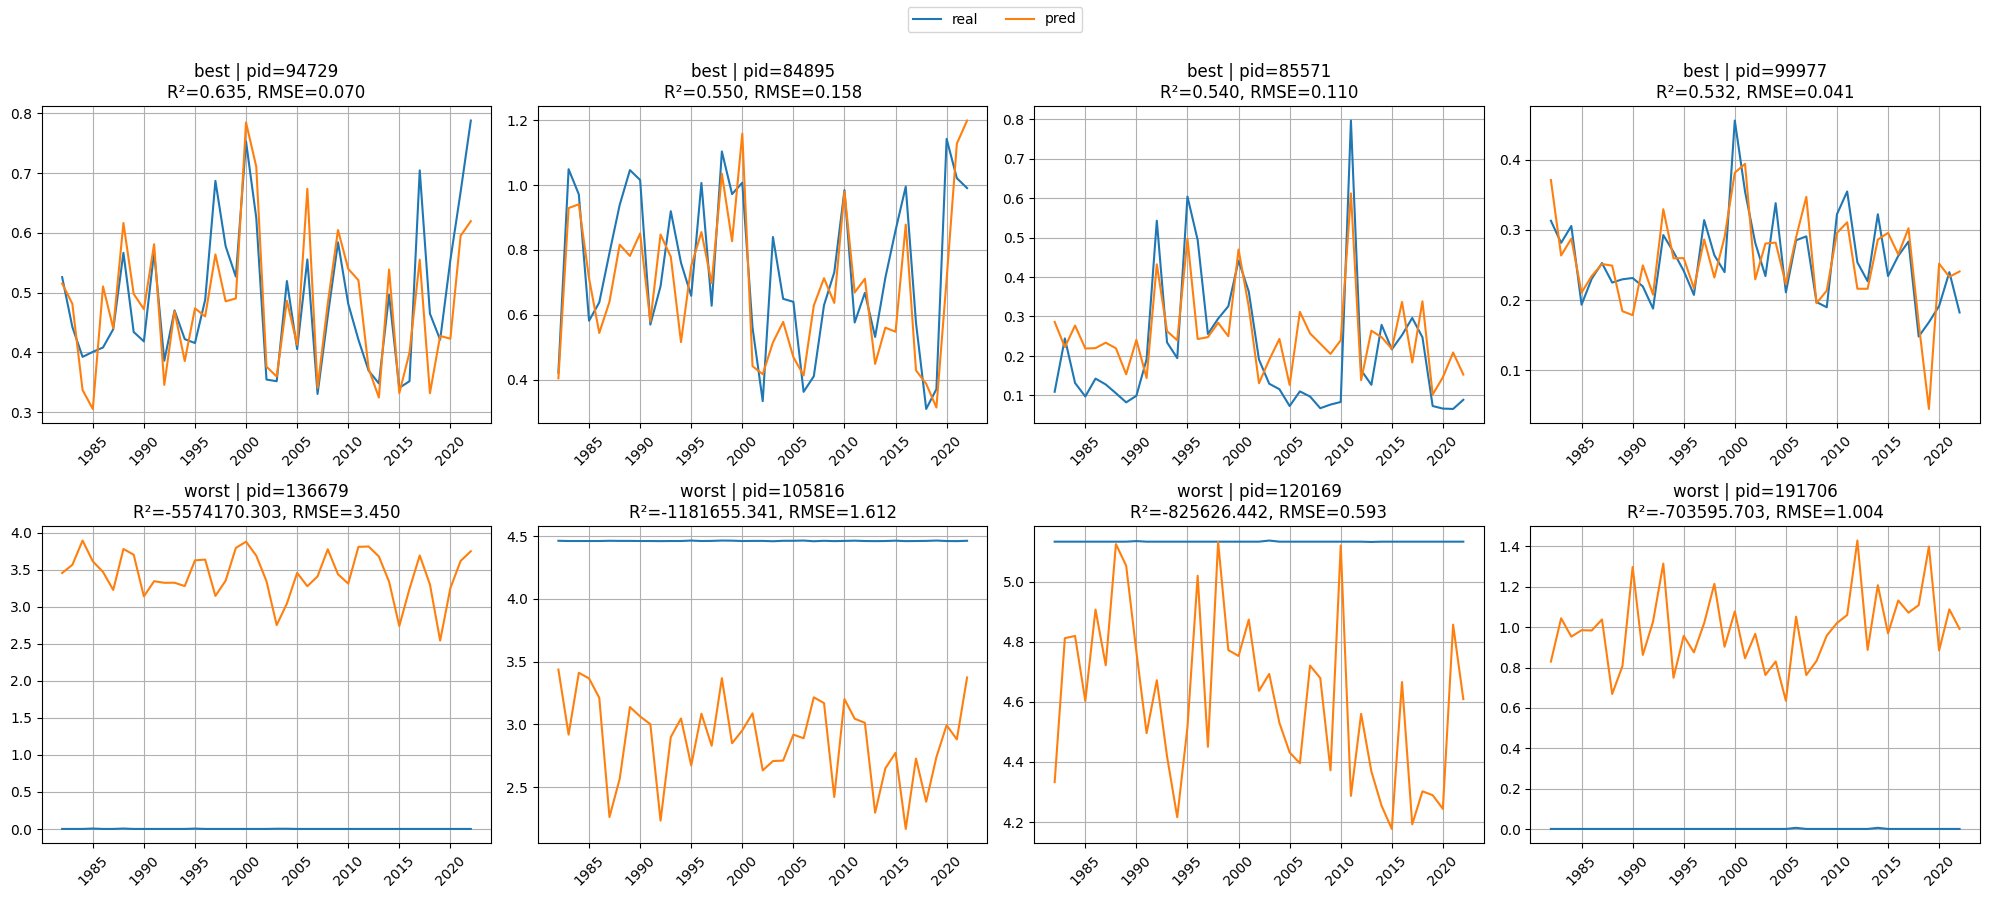

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=False)
axes = axes.ravel()

for ax, (_, row) in zip(axes, selected_pixels_density.iterrows()):
    pid = int(row["pixel_id"])
    sub = test_df[test_df["pixel_id"] == pid].copy().sort_values("time")

    if len(sub) == 0:
        ax.set_visible(False)
        continue

    ax.plot(sub["time"], sub["y_true"], label="real")
    ax.plot(sub["time"], sub["y_pred"], label="pred")
    ax.set_title(
        f"{row['group']} | pid={pid}\nR²={row['r2']:.3f}, RMSE={row['rmse']:.3f}"
    )
    ax.tick_params(axis="x", rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Tablas de apoyo: 4 mejores y 4 peores con coordenadas

In [39]:
display(top4_best[["pixel_id", "n_samples", "r2", "rmse", "mae", "lat_idx", "lon_idx", "latitude", "longitude"]])
display(top4_worst[["pixel_id", "n_samples", "r2", "rmse", "mae", "lat_idx", "lon_idx", "latitude", "longitude"]])

,pixel_id,n_samples,r2,rmse,mae,lat_idx,lon_idx,latitude,longitude
0,94729,41,0.635101,0.069851,0.053734,131,409,-24.5,24.5
1,84895,41,0.550081,0.157727,0.131246,117,655,-31.5,147.5
2,85571,41,0.540476,0.110115,0.093171,118,611,-31.0,125.5
3,99977,41,0.531618,0.040822,0.032701,138,617,-21.0,128.5


,pixel_id,n_samples,r2,rmse,mae,lat_idx,lon_idx,latitude,longitude
0,136679,41,-5.574170e+06,3.449707,3.435886,189,599,4.5,119.5
1,105816,41,-1.181655e+06,1.611597,1.577239,146,696,-17.0,168.0
2,120169,41,-8.256264e+05,0.593261,0.527462,166,649,-7.0,144.5
3,191706,41,-7.035957e+05,1.003813,0.987705,266,186,43.0,-87.0
